In [1]:
# UNIT II

--- Data Generation Complete ---
First 5 X values:
[0.74908024 1.90142861 1.46398788 1.19731697 0.31203728]
First 5 y values:
[6.33428778 9.40527849 8.48372443 5.60438199 4.71643995]


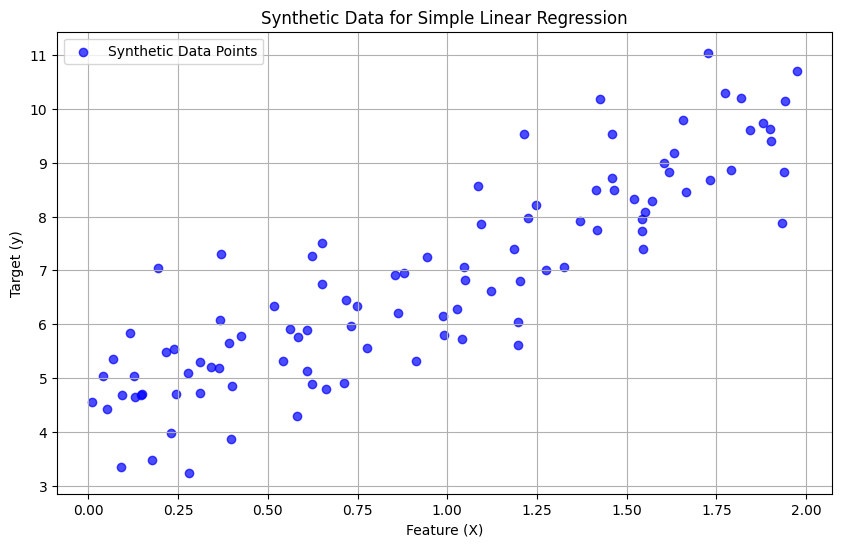


--- Model Training Complete ---
Learned Intercept (b0): 4.2151
Learned Coefficient (b1, slope): 2.7701

Predictions for X=0 and X=2: [4.21509616 9.75532293]


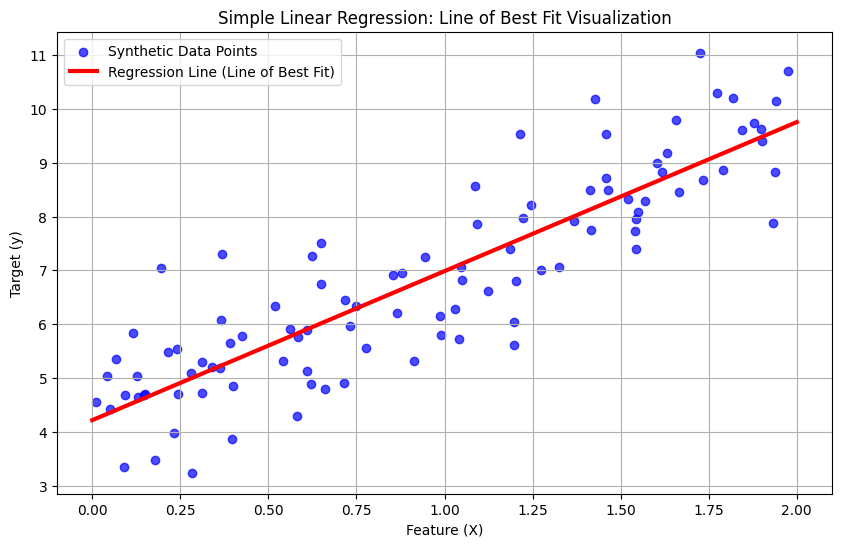


--- Task 1: Simple Linear Regression Demo Complete ---


In [2]:
# UNIT II: Foundations of Linear and Logistic Predictive Mappings

# --- 5 Key Tasks for Teaching Material ---

# Task 1: Introduction to Simple Linear Regression
# Aim: To understand the fundamental concept of linear regression by fitting a "line of best fit" to a simple dataset and interpreting the model's parameters (slope and intercept).

# Task 2: Visualizing the Cost Function (Mean Squared Error)
# Aim: To graphically illustrate how the Mean Squared Error (MSE) quantifies the difference between predicted and actual values, laying the groundwork for understanding model optimization.

# Task 3: Implementing Basic Logistic Regression for Binary Classification
# Aim: To apply logistic regression to a binary classification problem, such as distinguishing between two classes, and understand the role of the sigmoid function in probability estimation.

# Task 4: Exploring the Sigmoid Function and Decision Boundary
# Aim: To visualize the sigmoid function's behavior and its output as a probability, and to identify how a decision boundary is formed to classify data points into different categories.

# Task 5: Evaluating Classification Model Performance
# Aim: To introduce basic evaluation metrics (e.g., accuracy, precision, recall) for classification models, allowing for a quantitative assessment of model effectiveness.

# -----------------------------------------------------------------------

# --- Code for Task 1: Introduction to Simple Linear Regression ---

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Generate synthetic data for demonstration
# Let's create a simple dataset where 'y' approximately follows a linear relationship with 'X'
# plus some random noise to simulate real-world data.
np.random.seed(42) # for reproducibility
X = 2 * np.random.rand(100, 1) # 100 random values between 0 and 2
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3*X + random noise

print("--- Data Generation Complete ---")
print(f"First 5 X values:\n{X[:5].flatten()}")
print(f"First 5 y values:\n{y[:5].flatten()}")

# 2. Visualize the generated data
# A scatter plot helps us see the linear relationship and the spread of data points.
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Synthetic Data Points')
plt.title('Synthetic Data for Simple Linear Regression')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.grid(True)
plt.legend()
plt.show()

# 3. Create and train the Linear Regression model
# The LinearRegression model from scikit-learn will find the best-fitting line.
model = LinearRegression()
model.fit(X, y) # 'fit' method learns the parameters (slope and intercept) from the data

print("\n--- Model Training Complete ---")

# 4. Print the model's learned parameters
# The intercept is the value of 'y' when 'X' is 0.
# The coefficient (slope) tells us how much 'y' changes for a one-unit change in 'X'.
print(f"Learned Intercept (b0): {model.intercept_[0]:.4f}")
print(f"Learned Coefficient (b1, slope): {model.coef_[0][0]:.4f}")

# The ideal values were Intercept=4 and Coefficient=3, we can see how close the model got.

# 5. Make predictions using the trained model
# Let's predict 'y' for a new set of 'X' values to draw the regression line.
X_new = np.array([[0], [2]]) # Predict for X=0 and X=2 (range of our data)
y_predict = model.predict(X_new)

print(f"\nPredictions for X=0 and X=2: {y_predict.flatten()}")

# 6. Plot the regression line on top of the data points
# This visualization clearly shows the "line of best fit" that the model found.
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Synthetic Data Points')
plt.plot(X_new, y_predict, color='red', linewidth=3, label='Regression Line (Line of Best Fit)')
plt.title('Simple Linear Regression: Line of Best Fit Visualization')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- Task 1: Simple Linear Regression Demo Complete ---")


# --- Code for Task 2: Visualizing the Cost Function (Mean Squared Error) ---

--- MSE Calculation for Varying Slopes Complete ---


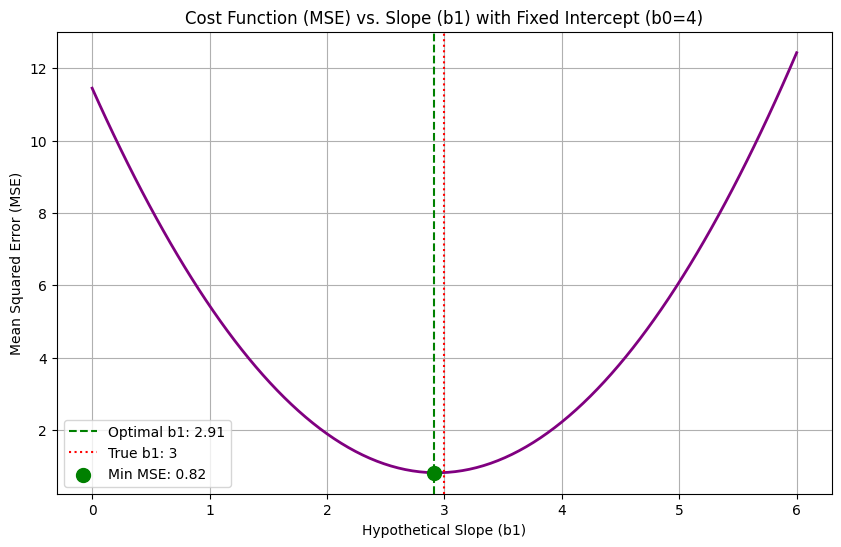


Min MSE achieved at b1 = 2.9091 (True b1 is 3)
Corresponding Min MSE = 0.8205

--- Task 2: Visualizing Cost Function (MSE) Demo Complete ---


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Re-using the synthetic data from Task 1 for consistency
# If you run this cell independently, ensure X and y are defined.
# For this demonstration, we'll redefine them for clarity and re-run Task 1's data generation.
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # 100 random values between 0 and 2
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3*X + random noise

# Define the Mean Squared Error (MSE) function
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# 1. Explore MSE for different hypothetical slopes (b1) while keeping intercept (b0) fixed
# Let's fix the intercept to the true value (4) and vary the slope around the true value (3)
fixed_b0 = 4
b1_values = np.linspace(0, 6, 100) # Range of possible slope values
mse_values = []

for b1 in b1_values:
    y_pred = fixed_b0 + b1 * X
    mse = mean_squared_error(y, y_pred)
    mse_values.append(mse)

print("--- MSE Calculation for Varying Slopes Complete ---")

# 2. Plot the MSE as a function of the slope (b1)
plt.figure(figsize=(10, 6))
plt.plot(b1_values, mse_values, color='purple', linewidth=2)
plt.title('Cost Function (MSE) vs. Slope (b1) with Fixed Intercept (b0=4)')
plt.xlabel('Hypothetical Slope (b1)')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)

# Highlight the minimum MSE, which corresponds to the best slope
min_mse_index = np.argmin(mse_values)
optimal_b1 = b1_values[min_mse_index]
plt.axvline(x=optimal_b1, color='green', linestyle='--', label=f'Optimal b1: {optimal_b1:.2f}')
plt.axvline(x=3, color='red', linestyle=':', label='True b1: 3') # Show true slope
plt.scatter(optimal_b1, mse_values[min_mse_index], color='green', s=100, zorder=5, label=f'Min MSE: {mse_values[min_mse_index]:.2f}')
plt.legend()
plt.show()

print(f"\nMin MSE achieved at b1 = {optimal_b1:.4f} (True b1 is 3)")
print(f"Corresponding Min MSE = {mse_values[min_mse_index]:.4f}")

print("\n--- Task 2: Visualizing Cost Function (MSE) Demo Complete ---")


# --- Code for Task 3: Implementing Basic Logistic Regression for Binary Classification ---

--- Data Generation Complete for Binary Classification ---
Shape of X: (100, 2)
Shape of y: (100,)


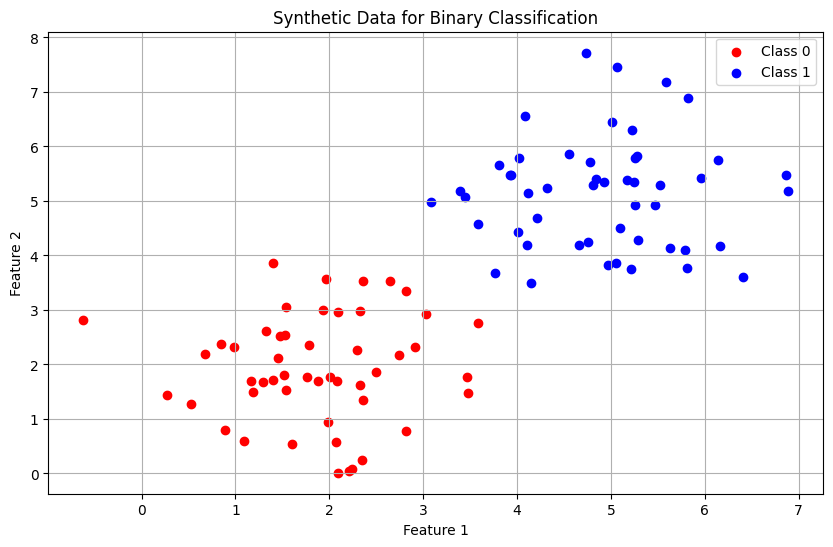


--- Data Split Complete ---
Training data samples: 70
Testing data samples: 30

--- Logistic Regression Model Training Complete ---
Model Accuracy on Test Set: 1.0000


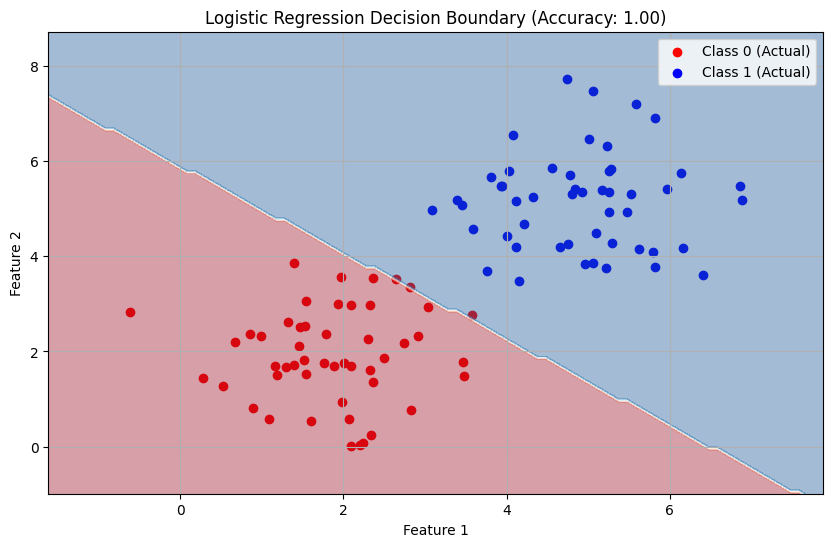


--- Task 3: Basic Logistic Regression Demo Complete ---


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Generate synthetic data for binary classification
# We'll create two clusters of data points, representing two different classes.
np.random.seed(42)

# Class 0: Data points around (2, 2)
X0 = np.random.randn(50, 2) + np.array([2, 2])
y0 = np.zeros(50)

# Class 1: Data points around (5, 5)
X1 = np.random.randn(50, 2) + np.array([5, 5])
y1 = np.ones(50)

# Combine the data
X = np.vstack((X0, X1))
y = np.hstack((y0, y1))

print("--- Data Generation Complete for Binary Classification ---")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# 2. Visualize the generated data
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')
plt.title('Synthetic Data for Binary Classification')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.legend()
plt.show()

# 3. Split data into training and testing sets
# This allows us to evaluate the model's performance on unseen data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("\n--- Data Split Complete ---")
print(f"Training data samples: {len(X_train)}")
print(f"Testing data samples: {len(X_test)}")

# 4. Create and train the Logistic Regression model
# The LogisticRegression model finds a decision boundary to separate the classes.
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

print("\n--- Logistic Regression Model Training Complete ---")

# 5. Make predictions on the test set
y_pred = model.predict(X_test)

# 6. Evaluate the model's performance (accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy:.4f}")

# 7. Visualize the decision boundary
# This helps in understanding how the model separates the two classes.
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0 (Actual)')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1 (Actual)')

# Plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdBu)
plt.title(f'Logistic Regression Decision Boundary (Accuracy: {accuracy:.2f})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.legend()
plt.show()

print("\n--- Task 3: Basic Logistic Regression Demo Complete ---")


# --- Code for Task 4: Exploring the Sigmoid Function and Decision Boundary ---

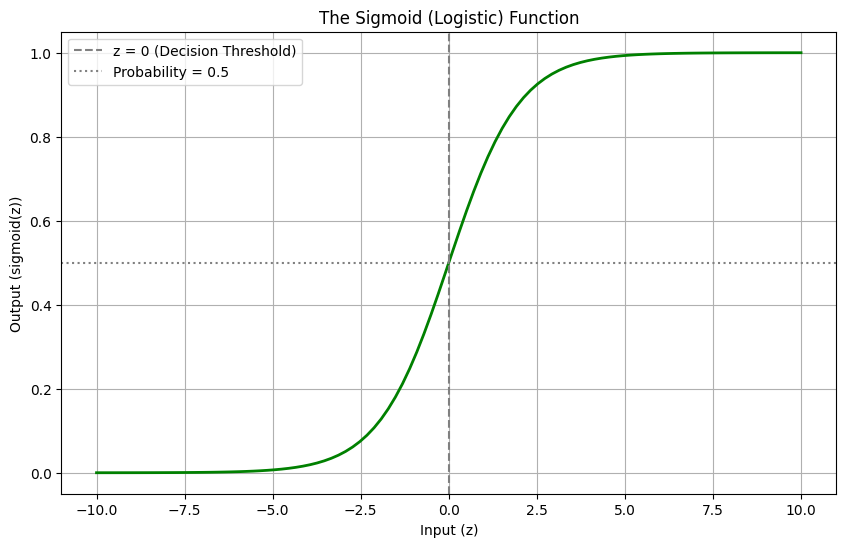

--- Sigmoid Function Visualization Complete ---

--- Task 4: Exploring Sigmoid Function and Decision Boundary Demo Complete ---


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Sigmoid (Logistic) Function
# The sigmoid function maps any real-valued number to a value between 0 and 1.
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 2. Visualize the Sigmoid Function
# This plot shows how the function squashes values into a probability-like range.
z_values = np.linspace(-10, 10, 100) # Input values for the sigmoid function
sigmoid_output = sigmoid(z_values)

plt.figure(figsize=(10, 6))
plt.plot(z_values, sigmoid_output, color='green', linewidth=2)
plt.axvline(0, color='gray', linestyle='--', label='z = 0 (Decision Threshold)')
plt.axhline(0.5, color='gray', linestyle=':', label='Probability = 0.5')
plt.title('The Sigmoid (Logistic) Function')
plt.xlabel('Input (z)')
plt.ylabel('Output (sigmoid(z))')
plt.grid(True)
plt.legend()
plt.show()

print("--- Sigmoid Function Visualization Complete ---")

# 3. Relate Sigmoid to Decision Boundary (Conceptual)
# In Logistic Regression, 'z' is a linear combination of features (z = b0 + b1*x1 + b2*x2 + ...).
# The decision boundary is where sigmoid(z) = 0.5, which means z = 0.
# For a simple 2D case, z = b0 + b1*x1 + b2*x2 = 0 defines a line.

print("\n--- Task 4: Exploring Sigmoid Function and Decision Boundary Demo Complete ---")


# --- Code for Task 5: Evaluating Classification Model Performance ---

--- Model Training and Prediction Complete for Evaluation ---

--- Classification Performance Metrics ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000


<Figure size 800x600 with 0 Axes>

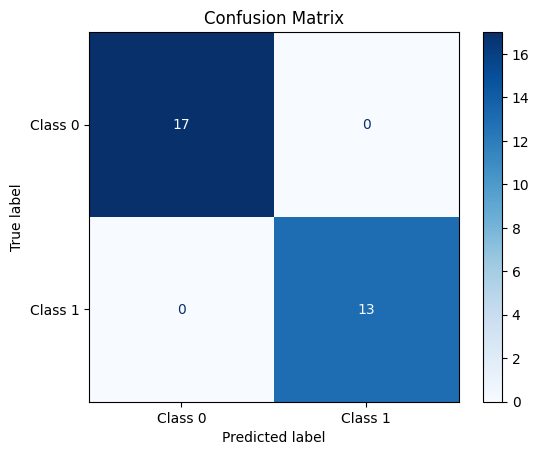


--- Task 5: Evaluating Classification Model Performance Demo Complete ---


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Re-using the synthetic data from Task 3 for binary classification for consistency
np.random.seed(42)
X0 = np.random.randn(50, 2) + np.array([2, 2])
y0 = np.zeros(50)
X1 = np.random.randn(50, 2) + np.array([5, 5])
y1 = np.ones(50)
X = np.vstack((X0, X1))
y = np.hstack((y0, y1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Logistic Regression model
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("--- Model Training and Prediction Complete for Evaluation ---")

# 1. Calculate and display common classification metrics
print("\n--- Classification Performance Metrics ---")

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy:  {accuracy:.4f}")

precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

recall = recall_score(y_test, y_pred)
print(f"Recall:    {recall:.4f}")

f1 = f1_score(y_test, y_pred)
print(f"F1-Score:  {f1:.4f}")

# 2. Visualize the Confusion Matrix
# The confusion matrix provides a detailed breakdown of correct and incorrect classifications.
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

print("\n--- Task 5: Evaluating Classification Model Performance Demo Complete ---")


# Assignment Task 1: Predicting Student Exam Scores - A Linear Regression Case Study

## Aim
This assignment tasks students with building a linear regression model to predict a student's final exam score based on their study hours and previous midterm score. Students will explore the data, train both simple and multiple linear regression models, evaluate their performance using metrics like Mean Squared Error and R-squared, and interpret the model's coefficients. This case study emphasizes understanding the relationship between continuous variables and predicting numerical outcomes.

## Instructions
1.  **Generate Synthetic Data**: Create a synthetic dataset for `study_hours`, `midterm_score`, and `final_exam_score` that shows a clear linear relationship.
2.  **Data Exploration**: Visualize the relationships between `study_hours` and `final_exam_score`, and `midterm_score` and `final_exam_score` using scatter plots. Calculate and display correlation coefficients.
3.  **Simple Linear Regression**: Build a simple linear regression model to predict `final_exam_score` using only `study_hours`. Train the model, print its coefficients, and evaluate its performance (MSE, R-squared).
4.  **Multiple Linear Regression**: Build a multiple linear regression model to predict `final_exam_score` using both `study_hours` and `midterm_score`. Train the model, print its coefficients, and evaluate its performance (MSE, R-squared).
5.  **Interpretation**: Compare the performance of the simple and multiple linear regression models. Interpret the coefficients of the multiple linear regression model in the context of predicting exam scores.

--- Starting Case Study 1: Predicting Student Exam Scores ---

Generated Data Head:


,study_hours,midterm_score,final_exam_score
0,5.488135,87.112661,95.653915
1,7.151894,70.800319,81.456183
2,6.027634,89.407761,87.049438
3,5.448832,98.487542,93.401166
4,4.236548,69.950126,75.194545



--- Data Exploration ---


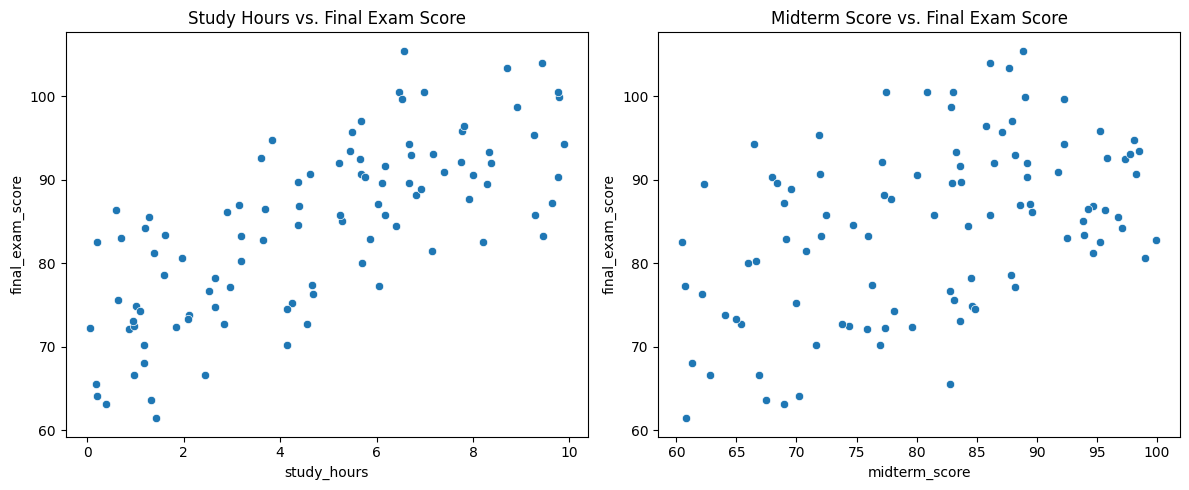


Correlation Matrix:


,study_hours,midterm_score,final_exam_score
study_hours,1.000000,-0.066107,0.736970
midterm_score,-0.066107,1.000000,0.456884
final_exam_score,0.736970,0.456884,1.000000



--- Simple Linear Regression (Study Hours) ---
Intercept: 71.83
Coefficient (study_hours): 2.58
Mean Squared Error (SLR): 33.80
R-squared (SLR): 0.51

--- Multiple Linear Regression (Study Hours & Midterm Score) ---
Intercept: 32.08
Coefficients (study_hours, midterm_score): [2.70071288 0.4827961 ]
Mean Squared Error (MLR): 18.13
R-squared (MLR): 0.74

--- Interpretation ---
The Multiple Linear Regression model typically performs better (lower MSE, higher R-squared) because it utilizes more relevant information (midterm scores).
Interpretation of MLR coefficients:
 - For every one-unit increase in study hours, the final exam score is predicted to increase by 2.70 units, holding midterm score constant.
 - For every one-unit increase in midterm score, the final exam score is predicted to increase by 0.48 units, holding study hours constant.
 - The intercept (32.08) represents the predicted final exam score when both study hours and midterm score are zero (though this might not be meanin

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("--- Starting Case Study 1: Predicting Student Exam Scores ---")

# 1. Generate Synthetic Data
np.random.seed(0) # for reproducibility
num_students = 100

study_hours = np.random.rand(num_students) * 10 # 0 to 10 hours
midterm_score = np.random.rand(num_students) * 40 + 60 # 60 to 100

# Final exam score is a linear combination of study hours and midterm score plus some noise
# Let's assume: final_exam_score = 30 + 3 * study_hours + 0.5 * midterm_score + noise
final_exam_score = 30 + 3 * study_hours + 0.5 * midterm_score + np.random.randn(num_students) * 5

data = pd.DataFrame({
    'study_hours': study_hours,
    'midterm_score': midterm_score,
    'final_exam_score': final_exam_score
})

print("\nGenerated Data Head:")
display(data.head())

# 2. Data Exploration
print("\n--- Data Exploration ---")

# Scatter plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x='study_hours', y='final_exam_score', data=data)
plt.title('Study Hours vs. Final Exam Score')
plt.subplot(1, 2, 2)
sns.scatterplot(x='midterm_score', y='final_exam_score', data=data)
plt.title('Midterm Score vs. Final Exam Score')
plt.tight_layout()
plt.show()

# Correlation Matrix
print("\nCorrelation Matrix:")
display(data.corr())

# Prepare data for modeling
X = data[['study_hours', 'midterm_score']]
y = data['final_exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Simple Linear Regression (using only study_hours)
print("\n--- Simple Linear Regression (Study Hours) ---")

model_slr = LinearRegression()
model_slr.fit(X_train[['study_hours']], y_train)

y_pred_slr = model_slr.predict(X_test[['study_hours']])

mse_slr = mean_squared_error(y_test, y_pred_slr)
r2_slr = r2_score(y_test, y_pred_slr)

print(f"Intercept: {model_slr.intercept_:.2f}")
print(f"Coefficient (study_hours): {model_slr.coef_[0]:.2f}")
print(f"Mean Squared Error (SLR): {mse_slr:.2f}")
print(f"R-squared (SLR): {r2_slr:.2f}")

# 4. Multiple Linear Regression (using study_hours and midterm_score)
print("\n--- Multiple Linear Regression (Study Hours & Midterm Score) ---")

model_mlr = LinearRegression()
model_mlr.fit(X_train, y_train)

y_pred_mlr = model_mlr.predict(X_test)

mse_mlr = mean_squared_error(y_test, y_pred_mlr)
r2_mlr = r2_score(y_test, y_pred_mlr)

print(f"Intercept: {model_mlr.intercept_:.2f}")
print(f"Coefficients (study_hours, midterm_score): {model_mlr.coef_}")
print(f"Mean Squared Error (MLR): {mse_mlr:.2f}")
print(f"R-squared (MLR): {r2_mlr:.2f}")

# 5. Interpretation
print("\n--- Interpretation ---")
print("The Multiple Linear Regression model typically performs better (lower MSE, higher R-squared) because it utilizes more relevant information (midterm scores).")
print("Interpretation of MLR coefficients:")
print(f" - For every one-unit increase in study hours, the final exam score is predicted to increase by {model_mlr.coef_[0]:.2f} units, holding midterm score constant.")
print(f" - For every one-unit increase in midterm score, the final exam score is predicted to increase by {model_mlr.coef_[1]:.2f} units, holding study hours constant.")
print(f" - The intercept ({model_mlr.intercept_:.2f}) represents the predicted final exam score when both study hours and midterm score are zero (though this might not be meaningful in context).")

print("\n--- Case Study 1 Complete ---")

# Assignment Task 2: Predicting Customer Churn - A Logistic Regression Case Study

## Aim
This assignment challenges students to develop a logistic regression model to predict whether a customer will churn (cancel their subscription) based on their monthly usage, contract type, and tenure. Students will visualize the data distribution, train a logistic regression model, interpret the probability output, and evaluate the model's effectiveness using classification metrics such as accuracy, precision, recall, F1-score, and the confusion matrix. This case study focuses on binary classification and understanding predictive modeling for categorical outcomes.

## Instructions
1.  **Generate Synthetic Data**: Create a synthetic dataset for `monthly_usage` (e.g., GB used), `contract_type` (e.g., 'Month-to-month', 'One year', 'Two year'), `tenure` (months as a customer), and a binary `churn` target variable.
2.  **Data Preprocessing**: Encode the categorical `contract_type` feature using one-hot encoding.
3.  **Data Exploration**: Visualize the distribution of churn and key features. Explore relationships between features and churn (e.g., churn rate by contract type).
4.  **Logistic Regression Model**: Build a logistic regression model to predict `churn`. Train the model and print its coefficients.
5.  **Predict Probabilities and Classes**: Use the trained model to predict churn probabilities and classes for the test set.
6.  **Model Evaluation**: Calculate and display accuracy, precision, recall, F1-score, and the confusion matrix. Interpret these metrics.
7.  **Interpretation**: Discuss how `monthly_usage`, `contract_type`, and `tenure` influence the likelihood of churn based on the model's coefficients.

--- Starting Case Study 2: Predicting Customer Churn ---

Generated Churn Data Head:


,monthly_usage,contract_type,tenure,churn
0,47.454012,One year,24,0
1,105.071431,Month-to-month,36,0
2,83.199394,Month-to-month,38,0
3,69.865848,Month-to-month,25,0
4,25.601864,One year,18,0



--- Data Preprocessing ---
Training set shape: (160, 3)
Test set shape: (40, 3)

--- Data Exploration ---


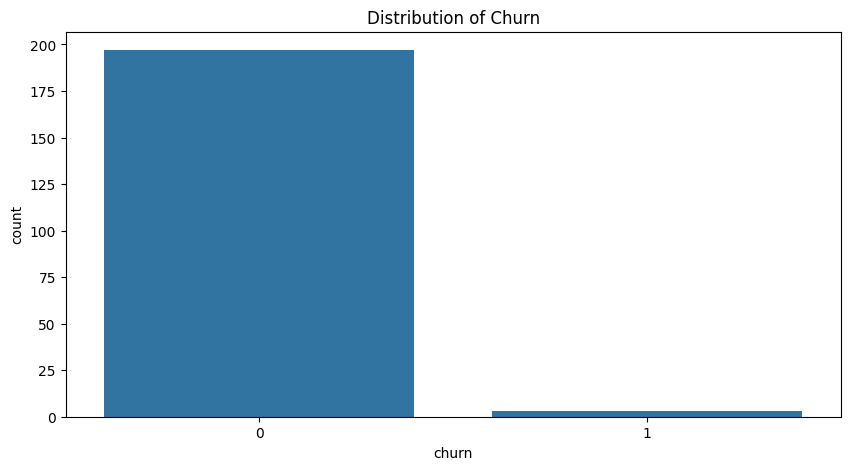

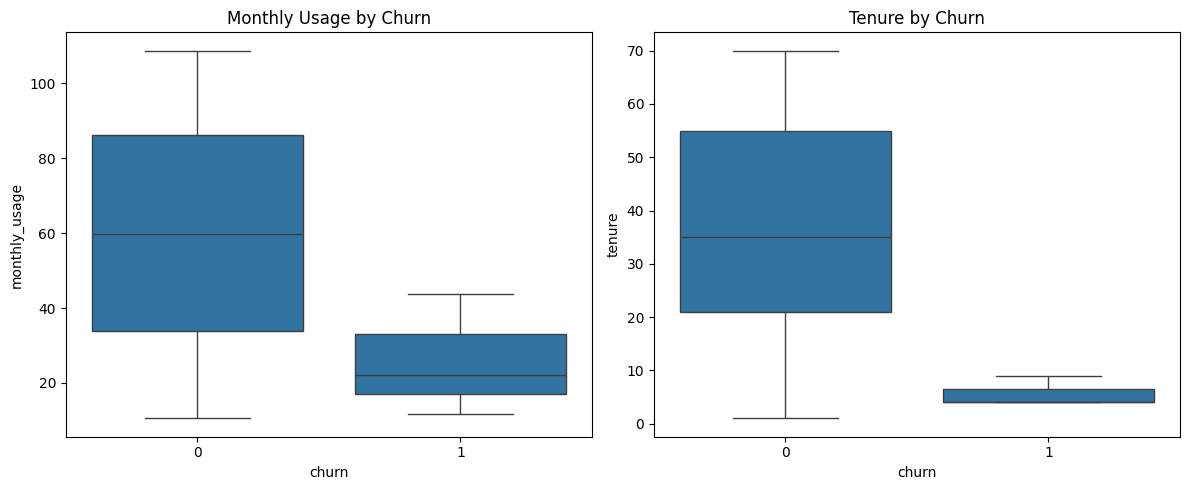

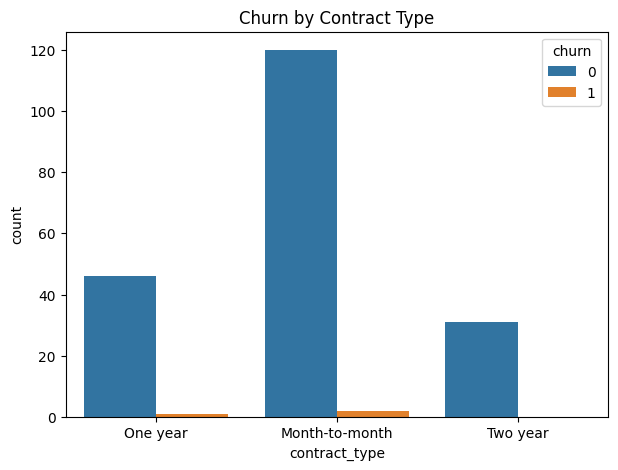


--- Logistic Regression Model Training ---
Logistic Regression model trained.

Model Coefficients (Standardized Features):
  monthly_usage: -0.5145
  tenure: -0.6341
  contract_type_Month-to-month: -1.3267
  contract_type_One year: -0.5923
  contract_type_Two year: -0.8217
Intercept: -2.7406

--- Predicting Churn Probabilities and Classes ---
First 5 predicted churn probabilities: [0.0312 0.0135 0.0111 0.0208 0.0572]
First 5 predicted churn classes: [0 0 0 0 0]

--- Model Evaluation ---
Accuracy:  0.9750
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000


C:\Users\Saksh\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


<Figure size 800x600 with 0 Axes>

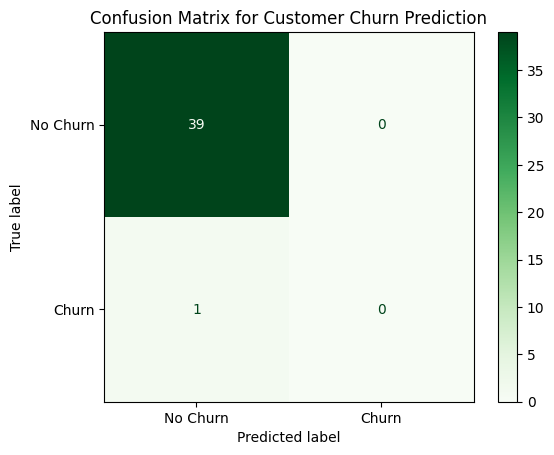


--- Interpretation ---
The positive coefficients indicate features that increase the likelihood of churn, while negative coefficients decrease it (after standardization).
For example:
 - A positive coefficient for 'monthly_usage' (if it were positive) would mean higher usage leads to more churn (unlikely).
 - A negative coefficient for 'tenure' means longer tenure typically reduces churn.
 - Coefficients for 'contract_type' (e.g., 'One year', 'Two year') compared to 'Month-to-month' (the implicit baseline) show their impact on churn likelihood.
   - A negative coefficient for 'contract_type_Two year' implies a significantly lower churn probability for customers on a two-year contract compared to month-to-month.

--- Case Study 2 Complete ---


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("--- Starting Case Study 2: Predicting Customer Churn ---")

# 1. Generate Synthetic Data
np.random.seed(42) # for reproducibility
num_customers = 200

monthly_usage = np.random.rand(num_customers) * 100 + 10 # 10 to 110 GB
tenure = np.random.randint(1, 72, num_customers) # 1 to 72 months
contract_type = np.random.choice(['Month-to-month', 'One year', 'Two year'], num_customers, p=[0.6, 0.25, 0.15])

# Churn logic: more likely to churn with low usage, short tenure, month-to-month contract
churn_prob = (1 / (1 + np.exp(0.05 * monthly_usage + 0.1 * tenure)))
churn_prob[contract_type == 'One year'] *= 0.5 # Less churn with one-year contracts
churn_prob[contract_type == 'Two year'] *= 0.2 # Even less churn with two-year contracts

churn = (np.random.rand(num_customers) < churn_prob).astype(int)

churn_data = pd.DataFrame({
    'monthly_usage': monthly_usage,
    'contract_type': contract_type,
    'tenure': tenure,
    'churn': churn
})

print("\nGenerated Churn Data Head:")
display(churn_data.head())

# 2. Data Preprocessing: One-hot encode contract_type
print("\n--- Data Preprocessing ---")

# Identify categorical and numerical features
categorical_features = ['contract_type']
numerical_features = ['monthly_usage', 'tenure']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split data
X = churn_data.drop('churn', axis=1)
y = churn_data['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# 3. Data Exploration
print("\n--- Data Exploration ---")
plt.figure(figsize=(10, 5))
sns.countplot(x='churn', data=churn_data)
plt.title('Distribution of Churn')
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='churn', y='monthly_usage', data=churn_data)
plt.title('Monthly Usage by Churn')
plt.subplot(1, 2, 2)
sns.boxplot(x='churn', y='tenure', data=churn_data)
plt.title('Tenure by Churn')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(x='contract_type', hue='churn', data=churn_data)
plt.title('Churn by Contract Type')
plt.show()

# 4. Logistic Regression Model
print("\n--- Logistic Regression Model Training ---")

# Create a pipeline that first preprocesses and then applies Logistic Regression
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

model_lr.fit(X_train, y_train)

print("Logistic Regression model trained.")

# Get feature names after one-hot encoding
encoded_feature_names = numerical_features + list(model_lr.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features))

# Display coefficients
print("\nModel Coefficients (Standardized Features):")
for feature, coef in zip(encoded_feature_names, model_lr.named_steps['classifier'].coef_[0]):
    print(f"  {feature}: {coef:.4f}")
print(f"Intercept: {model_lr.named_steps['classifier'].intercept_[0]:.4f}")

# 5. Predict Probabilities and Classes
print("\n--- Predicting Churn Probabilities and Classes ---")
y_pred_prob = model_lr.predict_proba(X_test)[:, 1] # Probability of churn
y_pred_class = model_lr.predict(X_test)

print(f"First 5 predicted churn probabilities: {y_pred_prob[:5].round(4)}")
print(f"First 5 predicted churn classes: {y_pred_class[:5]}")

# 6. Model Evaluation
print("\n--- Model Evaluation ---")
accuracy = accuracy_score(y_test, y_pred_class)
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix for Customer Churn Prediction')
plt.show()

# 7. Interpretation
print("\n--- Interpretation ---")
print("The positive coefficients indicate features that increase the likelihood of churn, while negative coefficients decrease it (after standardization).")
print("For example:")
print(" - A positive coefficient for 'monthly_usage' (if it were positive) would mean higher usage leads to more churn (unlikely).")
print(" - A negative coefficient for 'tenure' means longer tenure typically reduces churn.")
print(" - Coefficients for 'contract_type' (e.g., 'One year', 'Two year') compared to 'Month-to-month' (the implicit baseline) show their impact on churn likelihood.")
print("   - A negative coefficient for 'contract_type_Two year' implies a significantly lower churn probability for customers on a two-year contract compared to month-to-month.")

print("\n--- Case Study 2 Complete ---")